# Logistic Regression

You will implement logistic regression classifier.

Iris dataset with only 2 classes is provided to test the code.


In [15]:
import numpy as np
import pandas as pd
import numpy.matlib
import matplotlib.pyplot as plt

# read dataset
from google.colab import files
uploaded=files.upload()

df = pd.read_csv("shuffled_2class_iris_dataset.csv")
print(df.head())

df = df.values
np.random.shuffle(df)

X = df[:,0:4]   # 100x4
y = df[:,4]     # 100x1


Saving shuffled_2class_iris_dataset.csv to shuffled_2class_iris_dataset (2).csv
   sepal_width  sepal_length  petal_width  petal_length  class
0          5.6           3.0          4.1           1.3      0
1          5.4           3.9          1.7           0.4      1
2          5.6           3.0          4.5           1.5      0
3          5.0           3.5          1.6           0.6      1
4          5.5           2.4          3.7           1.0      0


In [16]:
# Feature scaling
max_min = X.max(0) - X.min(0)
Xmin = X.min(0)
X = (X-Xmin) / max_min

# Create 90/10 trainig/test sets
train_data = X[0:90,0:4]; train_label = y[0:90]
test_data = X[90:100,0:4]; test_label = y[90:100]


### Training

In [17]:
# Train the model using the training data

# Use batch gradient descent to find the optimal weights of the sigmoid function
# Experiment with different learning rates
# Run it for 2000 iterations.  You may change the number of iterations as you see fit.
np.random.seed(20)
w=np.random.rand(4)

epochs=2000
learning_rate = 0.1
costs = []
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_cost(X, y, w):
    m = len(y)
    z = X @ w.T
    h = sigmoid(z)
    cost = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost


def compute_gradient(X, y, w):
    m = len(y)
    z = X @ w.T
    h = sigmoid(z)
    gradient = (1/m) * X.T @ (h - y)
    return gradient


for epoch in range(epochs):
    cost = compute_cost(train_data, train_label, w)
    grad = compute_gradient(train_data, train_label, w)

    w = w - learning_rate * grad
    costs.append(cost)

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Cost: {cost:.4f}")





Epoch 0, Cost: 1.2341
Epoch 200, Cost: 0.2789
Epoch 400, Cost: 0.1784
Epoch 600, Cost: 0.1316
Epoch 800, Cost: 0.1049
Epoch 1000, Cost: 0.0877
Epoch 1200, Cost: 0.0757
Epoch 1400, Cost: 0.0668
Epoch 1600, Cost: 0.0600
Epoch 1800, Cost: 0.0546


### Testing

y   y_hat
0   0
1   1
0   0
1   1
1   1
1   1
1   1
1   1
0   0
0   0

Average accuracy = 100.00%


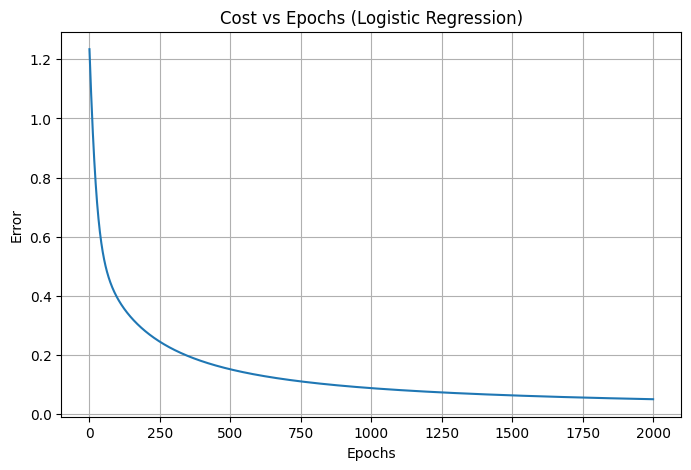

In [18]:
# Now use the test set to test the model

# Print the actual and predicted class labels
# Print the average accuracy

def predict(X, w):
    prob = sigmoid(X @ w.T)
    return (prob >= 0.5).astype(int)


# Predict on test set
y_pred = predict(test_data, w)
y_pred = y_pred.flatten()
test_label = test_label.flatten()
correct = 0


print("y   y_hat")
for i in range(len(test_label)):
    print(f"{int(test_label[i])}   {y_pred[i]}")
    if y_pred[i] == test_label[i]:
        correct += 1
accuracy = (correct / len(test_label)) * 100
print(f"\nAverage accuracy = {accuracy:.2f}%")

plt.figure(figsize=(8,5))
plt.plot(costs)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Cost vs Epochs (Logistic Regression)")
plt.grid(True)
plt.show()
